# Cane Corso Color Genetics — тестова проба

Учебна симулация за възможните цветове на малки Cane Corso според цветовите гени на родителите.

Идеята е да проверим какви цветове могат да се получат, когато бащата и майката имат различни цветове или носят различни скрити гени.

Това не е официален DNA тест и не е 100% генетична прогноза.  
Това е математическа и учебна проба, която показва вероятности според въведените от нас гени.

---

## Какво ще използваме?

Ще използваме опростен модел с два основни генетични слоя:

### 1. K locus

Той определя основния модел на цвета:

- `KB` = dominant black / черен ген
- `kbr` = brindle / тигров
- `ky` = fawn / рижав

За тази проба приемаме следната сила на гените:

`KB > kbr > ky`

Тоест черният ген е най-силен.  
Ако малкото получи поне един `KB`, основният цвят ще бъде черен.

---

### 2. D locus

Той определя дали цветът ще бъде нормален или разреден.

- `D/D` = нормален цвят
- `D/d` = нормален цвят, но кучето носи dilute ген
- `d/d` = разреден цвят

Пример:

- черен + `d/d` = сив / blue
- тигров + `d/d` = сиво-тигров / blue brindle
- fawn + `d/d` = разреден fawn нюанс

---

## Какво ще направим?


1. вземе гените на бащата
2. вземе гените на майката
3. направи всички възможни комбинации
4. определи възможния цвят на всяко малко
5. изчисли вероятностите в проценти
6. покаже таблица и графика

---

## Какъв ще бъде резултатът?

Накрая ще получим нещо от типа:

- черен — 50%
- сив / blue — 25%
- fawn / рижав — 25%

Резултатите зависят от това какви гени сме въвели за родителите.

---

## Важно уточнение

Видимият цвят на кучето не винаги показва всички скрити гени, които то носи.

Например черно куче може да носи скрит `ky` или `d` ген.  
Затова тази симулация е полезна за разбиране на вероятности, но за реална точност е нужен DNA тест.

Целта тук е да се научим как работи логиката:

**родители → гени → комбинации → вероятности за цвят**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from itertools import product

In [2]:
father = {
    "Име": "Баща",
    "K": ["KB", "ky"],
    "D": ["D", "d"]
}

mother = {
    "Име": "Майка",
    "K": ["ky", "ky"],
    "D": ["D", "d"]
}

In [3]:
def sort_k_genotype(k1, k2):
    dominance = {
        "KB": 3,   # dominant black
        "kbr": 2,  # brindle
        "ky": 1    # fawn
    }
    
    return tuple(sorted([k1, k2], key=lambda gene: dominance[gene], reverse=True))


def sort_d_genotype(d1, d2):
    dominance = {
        "D": 2,
        "d": 1
    }
    
    return tuple(sorted([d1, d2], key=lambda gene: dominance[gene], reverse=True))

In [4]:
def get_base_color(k_genotype):
    if "KB" in k_genotype:
        return "черен"
    elif "kbr" in k_genotype:
        return "тигров"
    else:
        return "fawn / рижав"

In [5]:
def apply_dilution(base_color, d_genotype):
    if d_genotype == ("d", "d"):
        if base_color == "черен":
            return "сив / blue"
        elif base_color == "тигров":
            return "сиво-тигров / blue brindle"
        else:
            return "разреден fawn"
    
    return base_color

In [6]:
puppies = []

for father_k, mother_k, father_d, mother_d in product(
    father["K"],
    mother["K"],
    father["D"],
    mother["D"]
):
    k_genotype = sort_k_genotype(father_k, mother_k)
    d_genotype = sort_d_genotype(father_d, mother_d)

    base_color = get_base_color(k_genotype)
    final_color = apply_dilution(base_color, d_genotype)

    puppies.append({
        "K генотип": "/".join(k_genotype),
        "D генотип": "/".join(d_genotype),
        "Основен цвят": base_color,
        "Краен предвиден цвят": final_color
    })

puppy_table = pd.DataFrame(puppies)

puppy_table

,K генотип,D генотип,Основен цвят,Краен предвиден цвят
0,KB/ky,D/D,черен,черен
1,KB/ky,D/d,черен,черен
2,KB/ky,D/d,черен,черен
3,KB/ky,d/d,черен,сив / blue
4,KB/ky,D/D,черен,черен
5,KB/ky,D/d,черен,черен
6,KB/ky,D/d,черен,черен
7,KB/ky,d/d,черен,сив / blue
8,ky/ky,D/D,fawn / рижав,fawn / рижав
9,ky/ky,D/d,fawn / рижав,fawn / рижав


In [7]:
color_probabilities = (
    puppy_table["Краен предвиден цвят"]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index()
)

color_probabilities.columns = ["Цвят", "Вероятност %"]

color_probabilities

,Цвят,Вероятност %
0,черен,37.5
1,fawn / рижав,37.5
2,сив / blue,12.5
3,разреден fawn,12.5


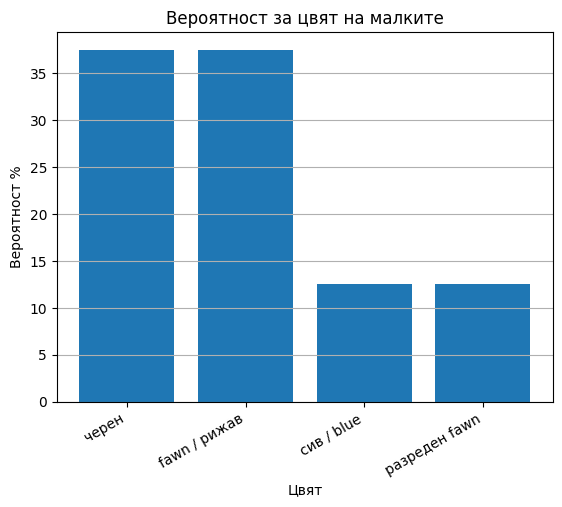

In [8]:
plt.bar(color_probabilities["Цвят"], color_probabilities["Вероятност %"])

plt.title("Вероятност за цвят на малките")
plt.xlabel("Цвят")
plt.ylabel("Вероятност %")
plt.xticks(rotation=30, ha="right")
plt.grid(axis="y")

plt.show()

In [9]:
assert len(puppy_table) > 0
assert round(color_probabilities["Вероятност %"].sum(), 2) == 100.00

print("Tests passed")

Tests passed


# Обобщение — какво направихме

Тестова проба за **Cane Corso Color Genetics**.

Целта беше да разберем как можем математически да симулираме възможни цветове при малките според гените на бащата и майката.

---

## 1. Определихме идеята

Първо уточнихме, че цветът не е число като тегло или височина.

Затова тук не използваме регресия, а използваме:

**генетична комбинация → възможен цвят → вероятност**

Тоест моделът не предсказва едно число, а изчислява вероятности за различни цветове.

---

## 2. Използвахме K locus

Въведохме опростена логика за K locus:

- `KB` = dominant black / черен ген
- `kbr` = brindle / тигров
- `ky` = fawn / рижав

Приехме следната сила на гените:

`KB > kbr > ky`

Това означава, че ако малкото получи поне един `KB`, основният цвят ще бъде черен.

---

## 3. Използвахме D locus

Добавихме и D locus, който показва дали цветът остава нормален или се разрежда.

- `D/D` = нормален цвят
- `D/d` = нормален цвят, но кучето носи dilute ген
- `d/d` = разреден цвят

Пример:

- черен + `d/d` = сив / blue
- тигров + `d/d` = сиво-тигров / blue brindle
- fawn + `d/d` = разреден fawn нюанс

---

## 4. Въведохме примерни родители

Създадохме примерни гени за баща и майка.

Пример:

```python
father = {
    "K": ["KB", "ky"],
    "D": ["D", "d"]
}

mother = {
    "K": ["ky", "ky"],
    "D": ["D", "d"]
}
```

Това означава, че бащата е черен, но може да носи скрит fawn и dilute ген, а майката е fawn и също носи dilute ген.

---

## 5. Python направи всички възможни комбинации

След това Python комбинира гените на бащата и майката.

За всяка възможна комбинация изчислихме:

- K генотип
- D генотип
- основен цвят
- краен предвиден цвят

---

## 6. Изчислихме вероятностите

Накрая преброихме колко пъти се появява всеки цвят и го превърнахме в процент.

Така получихме резултат от типа:

- черен — определен процент
- сив / blue — определен процент
- fawn / рижав — определен процент

---

## 7. Направихме графика

Показахме вероятностите с графика, за да се вижда по-ясно кой цвят има най-голям шанс да се появи при малките.

---

## 8. Добавихме тест

Накрая добавихме basic test, който проверява дали:

- таблицата с възможни малки е създадена
- вероятностите общо правят 100%

Това показва, че симулацията работи логически правилно.

---

## Важно уточнение

Това е учебна симулация, не официален DNA тест.

Видимият цвят на едно Cane Corso не винаги показва всички скрити гени, които кучето носи.

Затова за реална генетична точност е нужен DNA тест.

Този notebook служи за разбиране на логиката:

**родители → гени → комбинации → вероятности за цвят**

---

## Финален извод

Направихме проста математическа симулация, която показва как различни гени при бащата и майката могат да дадат различни вероятности за цвят при малките Cane Corso.

Това може да бъде основа за бъдещ модул:

**Cane Corso Color Genetics Simulator**